**Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import json
import os
import random
#from datasets import load_dataset


c:\Users\felip\teamlab-phonetics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading the dataset (training tensors)** 

In [9]:
# Set the directory containing the .pt files
data_dir = 'C:/Users/felip/teamlab-phonetics/feature_extraction/mel_segment_outputs/tensors_dev_set'

# Set the number of files to pick and the random seed
num_files_to_pick = 10
random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
random.seed(random_seed)

# Randomly select the specified number of files
selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, selected_files[0])  # Select the first file from the random selection

# Load the .pt file
inspect_data = torch.load(inspect_file)

# Print details about the file
print("Inspecting file:", inspect_file)
print("Type of data:", type(inspect_data))

# If the data is a tuple, inspect its elements
if isinstance(inspect_data, tuple):
    print("Tuple length:", len(inspect_data))
    for i, element in enumerate(inspect_data):
        print(f"Element {i} type:", type(element))
        if isinstance(element, torch.Tensor):
            print(f"Element {i} shape:", element.shape)
            print(f"Element {i} sample values:", element[:5])
else:
    # If it's a tensor, inspect directly
    if isinstance(inspect_data, torch.Tensor):
        print("Tensor shape:", inspect_data.shape)
        print("Sample values:", inspect_data[:1])
    else:
        print("Unknown data structure:", inspect_data)

## Initialize a list to store the concatenated data
#data_list = []
#
## Load the selected .pt files
#for file_name in selected_files:
#    file_path = os.path.join(data_dir, file_name)
#    data = torch.load(file_path)  # Assuming each .pt file contains a tuple or structure
#    if isinstance(data, tuple):
#        data = data[0]  # Extract the tensor if it's stored as the first element of a tuple
#    data_list.append(data)  # Append the tensor directly
#
## Concatenate all the data into a single tensor
#data_tensor = torch.cat(data_list, dim=0)
#
## Split the concatenated tensor into features and labels
#features = data_tensor[:, :-1]  # Assuming the last column is the label
#labels = data_tensor[:, -1]    # Assuming the last column is the label
#
## Create a TensorDataset and DataLoader
#dataset = TensorDataset(features, labels)
#dataLoader = DataLoader(dataset, batch_size=32, shuffle=True)

Inspecting file: C:/Users/felip/teamlab-phonetics/feature_extraction/mel_segment_outputs/tensors_dev_set\LA_D_8565273.pt
Type of data: <class 'tuple'>
Tuple length: 2
Element 0 type: <class 'torch.Tensor'>
Element 0 shape: torch.Size([128, 126])
Element 0 sample values: tensor([[-80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -78.2910, -80.0000, -80.0000, -80.0000,
         -78.9440, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -77.3670, -72.4759, -80.0000, -80.0000,
         -78.7921, -72.0665, -80.0000, -80.0000, -80.0000, -79.9099, -80.0000,
         -80.0000, -80.0000, -80.0000, -75.9245, -76.2124, -80.0000, -80.0000,
         -76.1356,

**Dataset inspection**

In [6]:
# Inspect the concatenated tensor
print("Data Tensor Shape:", data_tensor.shape)
print("Data Tensor Data Type:", data_tensor.dtype)
print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
print("Features Shape:", features.shape)
print("Labels Shape:", labels.shape)
print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:5])  # Print the first 5 labels

Data Tensor Shape: torch.Size([1280, 126])
Data Tensor Data Type: torch.float32
Sample Data Tensor Values:
 tensor([[-80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -78.2910, -80.0000, -80.0000, -80.0000,
         -78.9440, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -77.3670, -72.4759, -80.0000, -80.0000,
         -78.7921, -72.0665, -80.0000, -80.0000, -80.0000, -79.9099, -80.0000,
         -80.0000, -80.0000, -80.0000, -75.9245, -76.2124, -80.0000, -80.0000,
         -76.1356, -76.4353, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000, -80.0000,
         -80.0000, -80.

**Preprocessing Training Data**

In [ ]:
### creating the lists ###

label_bonafide = list()
label_activation = list()
features = list()

### creating the lists ###
for row in data.values():
    label_valence.append(row["valence"])
    label_activation.append(row["activation"])
    features.append(torch.tensor(row["features"]))

### Padding the features ###
all_features = torch.cat(features, dim=0)  # concatenate the features into a single tensor
mean_value = all_features.mean().item()    # Compute the mean across all features and dimensions (scalar)

# Compute mean and standard deviation of the original data (before padding)
mean = torch.mean(all_features, dim=0)  # Mean across all features (per-dimension)
std = torch.std(all_features, dim=0)    # Standard deviation across all features (per-dimension)

# Pad the features using the scalar mean_value as the padding value
padded_features = pad_sequence(features, batch_first=True, padding_value=mean_value)

# Normalize the padded features using the precomputed mean and std
padded_features = (padded_features - mean) / std

In [32]:
### Testing the preprocessing ###
print("Valence label:",label_valence[1],"Lenght:",len(label_valence))
print("Activation label:",label_activation[1],"Lenght:",len(label_valence))
print("Features lenght:",len(features), features[0].shape)
print("Padded features",padded_features)
print("Padded features shape",padded_features.shape)

Valence label: 1 Lenght: 7800
Activation label: 1 Lenght: 7800
Features lenght: 7800 torch.Size([147, 26])
Padded features tensor([[[ 0.3084, -0.2547, -0.5630,  ..., -0.0358, -0.4129, -0.4110],
         [-0.1584,  0.3242, -0.6663,  ..., -0.1960, -0.3752, -0.5181],
         [ 0.0448, -0.7533, -0.2257,  ..., -0.3137, -0.2466, -0.2184],
         ...,
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.1980],
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.1980],
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.1980]],

        [[ 0.0645, -0.2939, -1.1149,  ..., -1.1089, -1.0026, -0.7912],
         [-0.0142, -0.5409, -1.1222,  ..., -0.7286, -0.5892, -0.6681],
         [-0.0509, -0.7631, -0.8216,  ..., -0.7166, -0.3797, -0.5702],
         ...,
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.1980],
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.1980],
         [ 1.8102,  0.8478,  0.2321,  ..., -0.0306,  0.0770,  0.19

**Data Loader - Training Data**

In [4]:
combined_labels = torch.tensor([[float(label_activation), float(label_valence)] for label_activation, label_valence in zip(label_activation, label_valence)])
dataset = TensorDataset(padded_features, combined_labels) #easier way to load dataset without creating the DataSet Class
dataLoader = DataLoader(dataset, batch_size=32, shuffle=True)


**Testing the Data Loader**

In [38]:
print(len(dataset[0][0]))
print(padded_features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

1707
torch.Size([7800, 1707, 26])
Batch features shape: torch.Size([64, 1707, 26])


**Preprocessing and loading the Development/Validation Set**

In [5]:
# Load development data
dev_data = json.load(open('dev.json', 'r'))

# Preprocess development data (same as training data)
dev_label_valence = list()
dev_label_activation = list()
dev_features = list()

for row in dev_data.values():
    dev_label_valence.append(row["valence"])
    dev_label_activation.append(row["activation"])
    dev_features.append(torch.tensor(row["features"]))

# Pad the development features to the same length as the training set (1707)
target_length = 1707  # Same as training set
dev_padded_features = torch.zeros(len(dev_features), target_length, 26)  # Initialize with zeros

# Use the same padding value as the training data (e.g., mean_value)
for i, feature in enumerate(dev_features):
    seq_length = feature.size(0)
    if seq_length <= target_length:
        # Pad with the mean value if the sequence is shorter
        dev_padded_features[i, :seq_length, :] = feature
        dev_padded_features[i, seq_length:, :] = mean_value  # Fill the rest with the mean value
    else:
        # Truncate if the sequence is longer
        dev_padded_features[i, :, :] = feature[:target_length, :]

# Combine development labels
dev_combined_labels = torch.tensor([[float(label_activation), float(label_valence)] for label_activation, label_valence in zip(dev_label_activation, dev_label_valence)])

# Normalize the features using the training data's mean and std
dev_padded_features = (dev_padded_features - mean) / std

# Create a DataLoader for the development set
dev_dataset = TensorDataset(dev_padded_features, dev_combined_labels)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)

**Testing the Processed Dev Dataset**

In [36]:
print("Padded development features shape:", dev_padded_features.shape)

Padded development features shape: torch.Size([3342, 1707, 26])


**Neural Network Model**

In [6]:
class SentimentModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_prob=0.5):
        super(SentimentModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=26, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * (input_dim // 4), hidden_dim)  # Adjusted for two pooling layers
        self.fc3 = nn.Linear(hidden_dim, num_classes)
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        # Apply He initialization (for ReLU)
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Permute input to (batch_size, num_features, sequence_length)
        x = x.permute(0, 2, 1)
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = torch.sigmoid(self.fc3(x))  # Output layer: Sigmoid for binary classification
        
        return x

**Initializing the model**

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = 1707  # Sequence length after padding
hidden_dim = 128  # Number of neurons in the hidden layer
num_classes = 2   # Two outputs: valence and activation
dropout_prob = 0.5  # Dropout probability

model = SentimentModel(input_dim, hidden_dim, num_classes, dropout_prob).to(device)

**Loss function and Optimizer**

In [8]:
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)  # Learning rate of 0.001 + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [9]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_val_loss = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping


**Training Loop**

In [10]:
# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0
    
    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float())
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).all(dim=1).sum().item()
    
    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)
    
################# VALIDATION PHASE #####################
    model.eval()  # Set model to evaluation mode
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for features, labels in dev_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float())
            
            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).all(dim=1).sum().item()
    
    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_loader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)
    
    # Print metrics for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_loss_train:.4f}, Train Accuracy: {accuracy_train:.2f}%, '
          f'Val Loss: {avg_loss_val:.4f}, Val Accuracy: {accuracy_val:.2f}%')
    
    # Learning rate scheduling
    scheduler.step(avg_loss_val)  # Adjust learning rate based on validation loss
    
    # Early stopping
    if avg_loss_val < best_val_loss:
        best_val_loss = avg_loss_val
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/30], Train Loss: 0.6307, Train Accuracy: 38.28%, Val Loss: 0.5808, Val Accuracy: 43.99%
Epoch [2/30], Train Loss: 0.5973, Train Accuracy: 40.62%, Val Loss: 0.5787, Val Accuracy: 43.66%
Epoch [3/30], Train Loss: 0.5860, Train Accuracy: 43.59%, Val Loss: 0.5677, Val Accuracy: 46.77%
Epoch [4/30], Train Loss: 0.5801, Train Accuracy: 44.13%, Val Loss: 0.5675, Val Accuracy: 47.58%
Epoch [5/30], Train Loss: 0.5752, Train Accuracy: 45.85%, Val Loss: 0.5649, Val Accuracy: 48.50%
Epoch [6/30], Train Loss: 0.5627, Train Accuracy: 47.13%, Val Loss: 0.5542, Val Accuracy: 49.43%
Epoch [7/30], Train Loss: 0.5568, Train Accuracy: 47.87%, Val Loss: 0.5521, Val Accuracy: 49.61%
Epoch [8/30], Train Loss: 0.5485, Train Accuracy: 48.77%, Val Loss: 0.5480, Val Accuracy: 51.86%
Epoch [9/30], Train Loss: 0.5404, Train Accuracy: 49.68%, Val Loss: 0.5510, Val Accuracy: 51.41%
Epoch [10/30], Train Loss: 0.5335, Train Accuracy: 51.10%, Val Loss: 0.5450, Val Accuracy: 52.36%
Epoch [11/30], Train Loss: 0.

**Evaluation**

**Best result so far:**
1. CNN / 2 fully connected layers / 128 neurons / Early Stopping / Dropout / Adaptive Learning Rate
Testset result: 51.65%
Train / Validation Results: Epoch [16/30], Train Loss: 0.4955, Train Accuracy: 55.03%, Val Loss: 0.5561, Val Accuracy: 49.76%

Epoch [16/30], Train Loss: 0.4955, Train Accuracy: 55.03%, Val Loss: 0.5561, Val Accuracy: 49.76%


**Plotting the results**

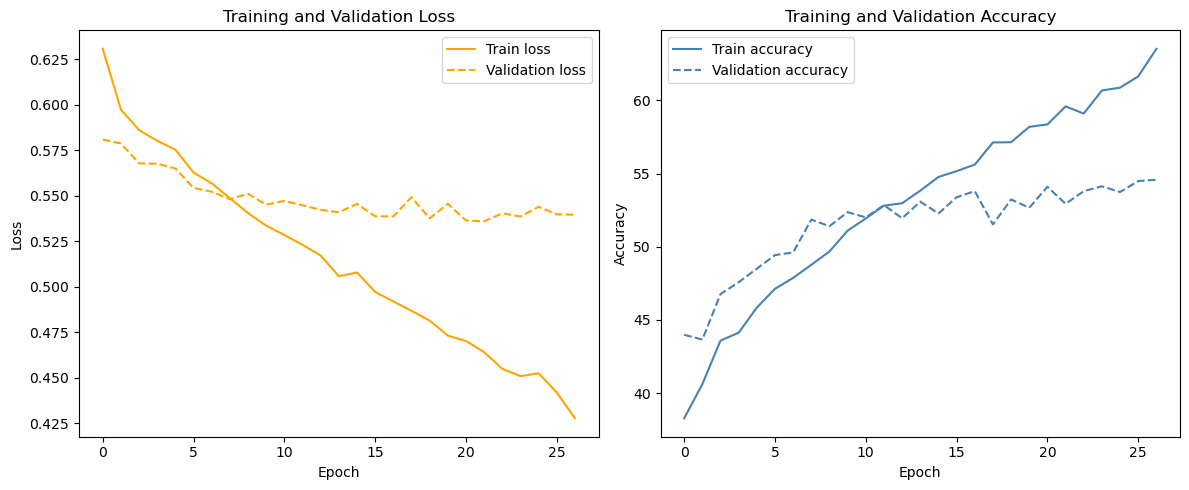

In [11]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [14]:
torch.save(model.state_dict(), 'sentiment_model.pth')

In [17]:
# Load test data
test_data = json.load(open('ser_test_2.json', 'r'))

# Preprocess test data
test_features = [torch.tensor(sample["features"]) for sample in test_data.values()]
unique_ids = list(test_data.keys())  # Extract unique IDs from the test file

# Pad the test features to the same length as the training set (1707)
target_length = 1707  # Same as training set
test_padded_features = torch.zeros(len(test_features), target_length, 26)  # Initialize with zeros

# Use the same padding value as the training data (e.g., mean_value)
for i, feature in enumerate(test_features):
    seq_length = feature.size(0)
    if seq_length <= target_length:
        # Pad with the mean value if the sequence is shorter
        test_padded_features[i, :seq_length, :] = feature
        test_padded_features[i, seq_length:, :] = mean_value  # Fill the rest with the mean value
    else:
        # Truncate if the sequence is longer
        test_padded_features[i, :, :] = feature[:target_length, :]

# Normalize the features using the training data's mean and std
# test_padded_features = (test_padded_features - mean) / std

# Create a DataLoader for the test set
test_dataset = TensorDataset(test_padded_features)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Make predictions
model.eval()  # Set model to evaluation mode
predictions_dict = {}

with torch.no_grad():
    for i, (features,) in enumerate(test_loader):  # Unpack features from the DataLoader
        features = features.to(device)
        outputs = model(features)
        predicted = (outputs > 0.5).float().cpu().numpy()  # Convert probabilities to binary predictions
        
        # Format predictions using the unique IDs from the test file
        for j, pred in enumerate(predicted):
            sample_id = unique_ids[i * 32 + j]  # Use the unique ID from the test file
            predictions_dict[sample_id] = {
                "valence": int(pred[1]),  # Valence prediction
                "activation": int(pred[0])  # Activation prediction
            }

# Save predictions to a JSON file
with open('predictions_ultimate_model.json', 'w') as f:
    json.dump(predictions_dict, f, indent=4)

print("Predictions saved with success")

Predictions saved with success


**Testing the model in the Test Set**

In [14]:
# Load test data
test_data = json.load(open('ser_test_2.json', 'r'))

# Preprocess test data
test_features = [torch.tensor(sample["features"]) for sample in test_data.values()]

# Pad the test features to the same length as the training set (1707)
target_length = 1707  # Same as training set
test_padded_features = torch.zeros(len(test_features), target_length, 26)  # Initialize with zeros

# Use the same padding value as the training data (e.g., mean_value)
for i, feature in enumerate(test_features):
    seq_length = feature.size(0)
    if seq_length <= target_length:
        # Pad with the mean value if the sequence is shorter
        test_padded_features[i, :seq_length, :] = feature
        test_padded_features[i, seq_length:, :] = mean_value  # Fill the rest with the mean value
    else:
        # Truncate if the sequence is longer
        test_padded_features[i, :, :] = feature[:target_length, :]

# Normalize the features using the training data's mean and std
#test_padded_features = (test_padded_features - mean) / std

# Create a DataLoader for the test set
test_dataset = TensorDataset(test_padded_features)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Make predictions
model.eval()  # Set model to evaluation mode
predictions_dict = {}

with torch.no_grad():
    for i, features in enumerate(test_loader):
        features = features[0].to(device)
        outputs = model(features)
        predicted = (outputs > 0.5).float().cpu().numpy()  # Convert probabilities to binary predictions
        
        # Format predictions
        for j, pred in enumerate(predicted):
            sample_id = str(i * 32 + j)  # Assuming batch size of 32
            predictions_dict[sample_id] = {
                "valence": int(pred[1]),  # Valence prediction
                "activation": int(pred[0])  # Activation prediction
            }

# Save predictions to a JSON file
with open('predictions_ultimate_model.json', 'w') as f:
    json.dump(predictions_dict, f, indent=4)

print("Predictions saved with success")

Predictions saved with success


In [15]:
unique_ids = list(test_data.keys())
print(unique_ids)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15

**Loading features and labels from .pt files**